# Spindown to New Steady State
Extracts the spin decay time τ from LES YAW_MON data using the Hilbert transform.

**Scenario:** Imaging laser provides radiation pressure torque spinning the disk. Inserting a 50/50
beamsplitter halves the laser power, causing the spin to decay from ~1 Hz to a new lower
steady-state frequency ~0.35 Hz (set by the reduced radiation pressure).  
**Method:** bandpass filter → Hilbert transform → instantaneous frequency → exponential fit  
**Model:** f(t) = f_ss + A · exp(−t/τ)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import h5py
from datetime import datetime, timezone
from scipy.signal import decimate, butter, sosfiltfilt, hilbert
from scipy.optimize import curve_fit
from scipy.ndimage import uniform_filter1d

In [2]:
FILENAME = '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/data/th228_sail/20250801/Y1_RDS-LES_YAW_MON_OUT_DQ_1437819028_1438164628.h5'

# GPS → UTC: GPS epoch is Jan 6 1980; 18 leap seconds as of 2025
GPS_UNIX_OFFSET = 315964800 - 18

def gps_to_dt(gps):
    return datetime.fromtimestamp(gps + GPS_UNIX_OFFSET, tz=timezone.utc)

def dt_to_gps(dt):
    return dt.timestamp() - GPS_UNIX_OFFSET

In [3]:
with h5py.File(FILENAME, 'r') as f:
    FS        = float(f.attrs['sample_rate'])
    gps_start = float(f.attrs['gps_start'])
    gps_end   = float(f.attrs['gps_end'])
    n_total   = f['data'].shape[0]

print(f"Rate:     {FS} Hz")
print(f"Samples:  {n_total:,}  ({n_total / FS / 3600:.2f} h)")
print(f"Start:    {gps_to_dt(gps_start)}")
print(f"End:      {gps_to_dt(gps_end)}")

Rate:     1024.0 Hz
Samples:  353,861,632  (95.99 h)
Start:    2025-07-29 10:10:10+00:00
End:      2025-08-02 10:10:10+00:00


## 2. Overview: Full Time Series
Strided read (every 256th sample → 4 Hz) for fast visual inspection.  
Use this to confirm the ringdown region, then set `RING_START` / `RING_END` below.

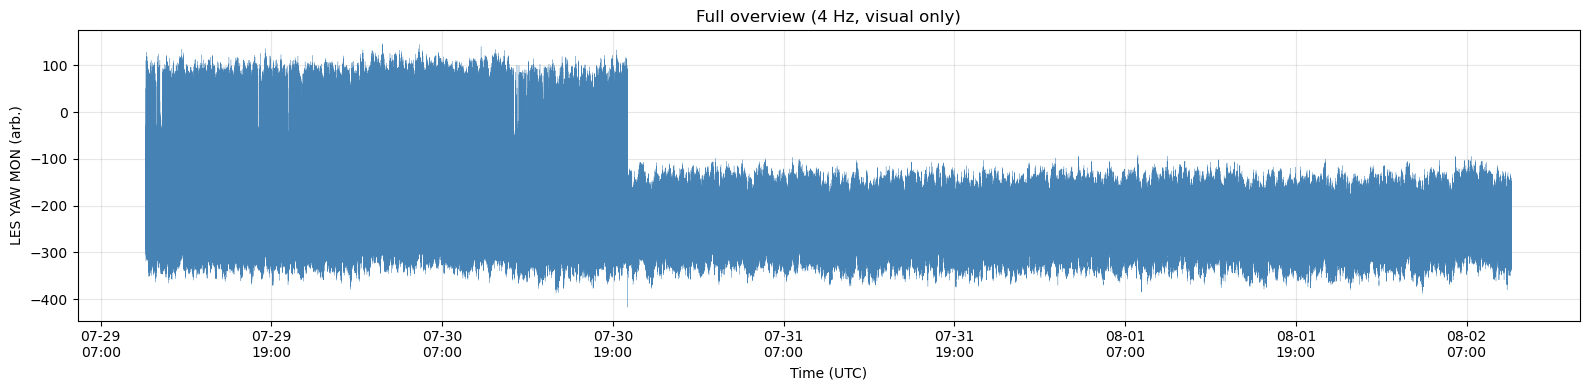

In [4]:
# Strided read — no anti-alias filter, for visual inspection only
STRIDE = 256  # 1024 Hz → 4 Hz
t_ov, y_ov = [], []

with h5py.File(FILENAME, 'r') as f:
    segs = f['segments/gps_start'][:].astype(np.float64)
    idxs = f['segments/index_start'][:].astype(np.int64)
    lens = f['segments/length'][:].astype(np.int64)
    dset = f['data']
    for gps0, ix, n in zip(segs, idxs, lens):
        y_seg = dset[ix : ix + n : STRIDE].astype(np.float32)
        t_seg = gps0 + np.arange(len(y_seg)) * STRIDE / 1024.0
        t_ov.append(t_seg)
        y_ov.append(y_seg)

t_ov = np.concatenate(t_ov)
y_ov = np.concatenate(y_ov)

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot([gps_to_dt(t) for t in t_ov], y_ov, linewidth=0.2, color='steelblue')
ax.set_xlabel('Time (UTC)')
ax.set_ylabel('LES YAW MON (arb.)')
ax.set_title('Full overview (4 Hz, visual only)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d\n%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=12))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
def load_channel(filename, fs_out=64.0, gps_t0=None, gps_t1=None):
    """Load an HDF5 channel, decimate to fs_out Hz. Optionally restrict to [gps_t0, gps_t1]."""
    t_list, y_list = [], []
    with h5py.File(filename, 'r') as f:
        fs   = float(f.attrs['sample_rate'])
        segs = f['segments/gps_start'][:].astype(np.float64)
        idxs = f['segments/index_start'][:].astype(np.int64)
        lens = f['segments/length'][:].astype(np.int64)
        dset = f['data']
        for gps0, ix, n in zip(segs, idxs, lens):
            gps1 = gps0 + n / fs
            if gps_t0 and gps1 < gps_t0: continue
            if gps_t1 and gps0 > gps_t1: continue
            seg = dset[ix : ix + n].astype(np.float64)
            seg = decimate(decimate(seg, 4, zero_phase=True), 4, zero_phase=True)  # ÷16 → 64 Hz
            t_seg = gps0 + np.arange(len(seg)) / fs_out
            t_list.append(t_seg)
            y_list.append(seg)
    t = np.concatenate(t_list)
    y = np.concatenate(y_list)
    if gps_t0: mask = t >= gps_t0; t, y = t[mask], y[mask]
    if gps_t1: mask = t <= gps_t1; t, y = t[mask], y[mask]
    return t, y

# ── Set window: 1h before ringdown start, extend past steady-state ────────────
RING_START = datetime(2025, 7, 30, 19, 0, 0, tzinfo=timezone.utc)
RING_END   = datetime(2025, 7, 30, 22, 30, 0, tzinfo=timezone.utc)
# ─────────────────────────────────────────────────────────────────────────────

gps_t0 = dt_to_gps(RING_START)
gps_t1 = dt_to_gps(RING_END)

FS_RING = 64.0
t_yaw, y_yaw = load_channel(FILENAME, FS_RING, gps_t0, gps_t1)
print(f"YAW: {len(y_yaw):,} samples  {gps_to_dt(t_yaw[0])} → {gps_to_dt(t_yaw[-1])}")

YAW: 806,401 samples  2025-07-30 19:00:00+00:00 → 2025-07-30 22:30:00+00:00


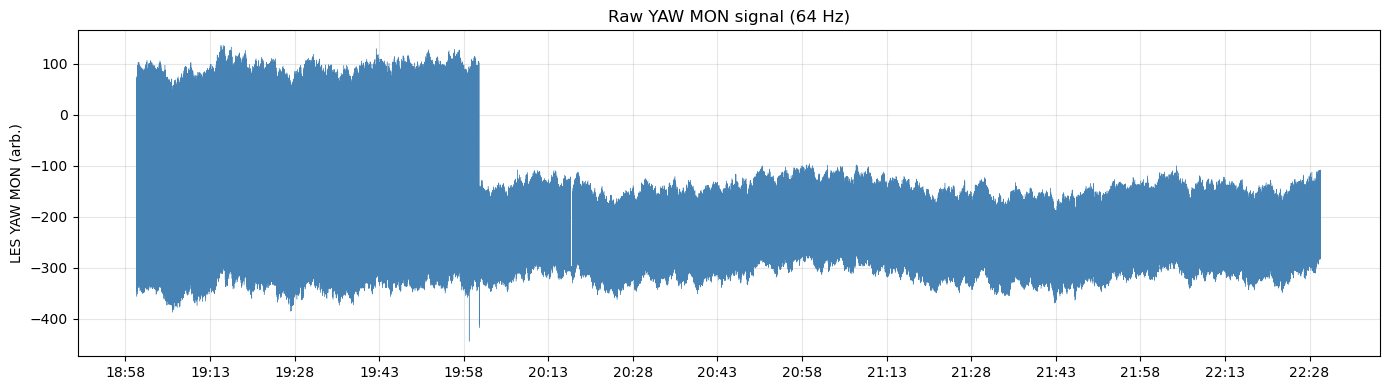

In [6]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot([gps_to_dt(t) for t in t_yaw], y_yaw, linewidth=0.3, color='steelblue')
ax.set_ylabel('LES YAW MON (arb.)')
ax.set_title('Raw YAW MON signal (64 Hz)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=15))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Bandpass Filter
Zero-phase Butterworth bandpass to isolate the spin signal.  
Range covers both the initial driven frequency (~1 Hz) and the steady-state (~0.35 Hz).

In [7]:
# ── Adjust if spin frequency range is different ───────────────────────────────
F_LOW  = 0.1   # Hz – removes DC drift
F_HIGH = 2.0   # Hz – above the initial spin frequency
# ─────────────────────────────────────────────────────────────────────────────

sos     = butter(4, [F_LOW, F_HIGH], btype='bandpass', fs=FS_RING, output='sos')
y_yaw_f = sosfiltfilt(sos, y_yaw)
print(f"Bandpass applied: {F_LOW}–{F_HIGH} Hz")

Bandpass applied: 0.1–2.0 Hz


## 4. Hilbert Transform: Instantaneous Amplitude and Frequency

In [8]:
def hilbert_freq(y_filt, fs, smooth_sec=30.0):
    """Return (inst_freq, envelope, dt_half) — all arrays length N-1, aligned."""
    analytic  = hilbert(y_filt)
    envelope  = np.abs(analytic)
    phase     = np.unwrap(np.angle(analytic))
    dt        = 1.0 / fs
    inst_freq = np.diff(phase) / (2 * np.pi * dt)
    win       = max(1, int(smooth_sec * fs))
    return (uniform_filter1d(inst_freq,      size=win),
            uniform_filter1d(envelope[:-1],  size=win),
            dt / 2)

# ── Smoothing window ──────────────────────────────────────────────────────────
SMOOTH_SEC = 30.0
# ─────────────────────────────────────────────────────────────────────────────

freq_yaw, env_yaw, dt_half = hilbert_freq(y_yaw_f, FS_RING, SMOOTH_SEC)
t_freq_yaw = t_yaw[:-1] + dt_half

print(f"Array lengths — freq: {len(freq_yaw)}, envelope: {len(env_yaw)}  (should match)")
print(f"YAW freq range: {freq_yaw.min():.3f} – {freq_yaw.max():.3f} Hz")

Array lengths — freq: 806400, envelope: 806400  (should match)
YAW freq range: 0.310 – 1.009 Hz


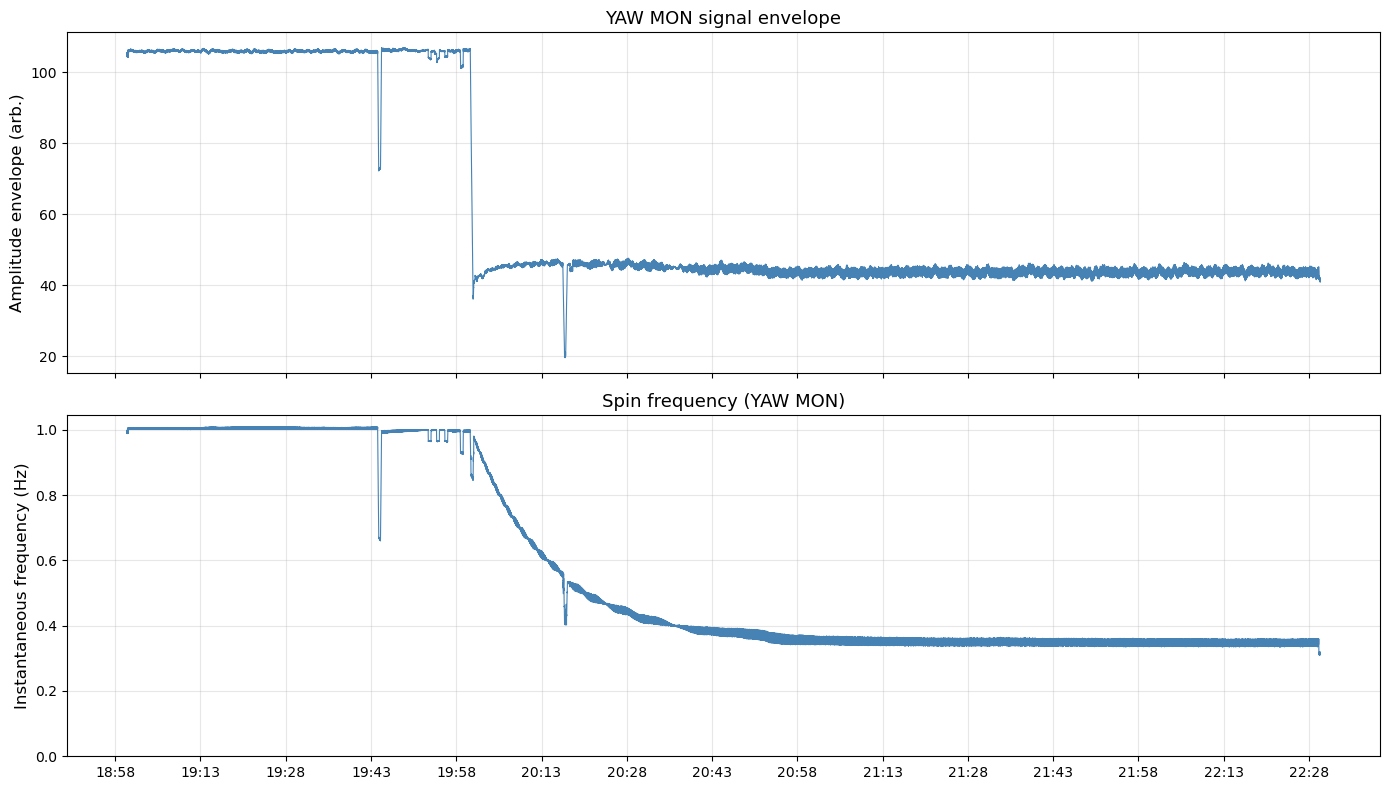

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot([gps_to_dt(t) for t in t_freq_yaw], env_yaw, linewidth=0.8, color='steelblue')
axes[0].set_ylabel('Amplitude envelope (arb.)', fontsize=12)
axes[0].set_title('YAW MON signal envelope', fontsize=13)
axes[0].grid(True, alpha=0.3)

axes[1].plot([gps_to_dt(t) for t in t_freq_yaw], freq_yaw, linewidth=0.8, color='steelblue')
axes[1].set_ylabel('Instantaneous frequency (Hz)', fontsize=12)
axes[1].set_title('Spin frequency (YAW MON)', fontsize=13)
axes[1].set_ylim(bottom=0)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axes[1].xaxis.set_major_locator(mdates.MinuteLocator(interval=15))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Exponential Fit: Ringdown to Steady State
Fit f(t) = f_ss + A · exp(−γt) to the decaying portion.  
- `f_ss` is estimated from the stable tail and can be overridden  
- `F_MAX_FIT`: just below the initial plateau frequency  
- `F_MIN_FIT`: just above f_ss to exclude the noisy settled region  

τ = 1/γ is the 1/e ringdown time.

In [14]:
# ── Fit parameters ────────────────────────────────────────────────────────────
F_MAX_FIT   = 0.95   # Hz – below the initial driven plateau (~1 Hz)
F_MIN_FIT   = 0.42   # Hz – above the steady state to exclude settled noise
AMP_THRESH  = 0.05   # fraction of peak envelope — exclude very low amplitude
T_SKIP_SEC  = 60     # skip filter edge transient at start

# Hard cutoff: exclude everything before beamsplitter insertion + glitch at ~20:10-20:13
DECAY_START = datetime(2025, 7, 30, 20, 15, 0, tzinfo=timezone.utc)
# ─────────────────────────────────────────────────────────────────────────────

amp_peak       = env_yaw.max()
t_start        = t_freq_yaw[0] + T_SKIP_SEC
decay_start_gps = dt_to_gps(DECAY_START)

fit_mask = (
    (freq_yaw    > F_MIN_FIT) &
    (freq_yaw    < F_MAX_FIT) &
    (env_yaw     > AMP_THRESH * amp_peak) &
    (t_freq_yaw  > t_start) &
    (t_freq_yaw  > decay_start_gps)
)

t_fit_gps = t_freq_yaw[fit_mask]
f_fit     = freq_yaw[fit_mask]

# Estimate f_ss from the flat tail (freq below F_MIN_FIT + small margin)
tail_mask = (freq_yaw > 0.2) & (freq_yaw < F_MIN_FIT) & (t_freq_yaw > t_start)
if tail_mask.sum() > 10:
    f_ss = np.median(freq_yaw[tail_mask])
else:
    f_ss = F_MIN_FIT * 0.9  # fallback
print(f"Estimated f_ss = {f_ss:.4f} Hz")
print(f"DECAY_START    = {DECAY_START}")

print(f"Fit region: {len(f_fit)} points")
if len(f_fit) > 0:
    print(f"  {gps_to_dt(t_fit_gps[0])} → {gps_to_dt(t_fit_gps[-1])}")
    print(f"  span: {(t_fit_gps[-1] - t_fit_gps[0]) / 60:.1f} min")
    print(f"  freq range: {f_fit.min():.3f} – {f_fit.max():.3f} Hz")

Estimated f_ss = 0.3526 Hz
DECAY_START    = 2025-07-30 20:15:00+00:00
Fit region: 63984 points
  2025-07-30 20:15:00.007812+00:00 → 2025-07-30 20:34:08.679688+00:00
  span: 19.1 min
  freq range: 0.420 – 0.596 Hz


In [11]:
if len(f_fit) < 20:
    print("WARNING: too few points — adjust F_MIN_FIT / F_MAX_FIT or RING_START / RING_END")
else:
    t0  = t_fit_gps[0]
    t_s = t_fit_gps - t0

    def exp_decay_ss(t, A, gamma):
        return f_ss + A * np.exp(-gamma * t)

    popt, pcov = curve_fit(exp_decay_ss, t_s, f_fit,
                           p0=[f_fit[0] - f_ss, 1.0/800], maxfev=10000)
    A_fit, gamma_fit = popt
    A_err, gamma_err = np.sqrt(np.diag(pcov))

    tau     = 1.0 / gamma_fit
    tau_err = gamma_err / gamma_fit**2

    print(f"=== Ringdown Results ===")
    print(f"γ   = {gamma_fit:.6f} ± {gamma_err:.6f}  s⁻¹")
    print(f"τ   = {tau:.1f} ± {tau_err:.1f}  s")
    print(f"τ   = {tau/60:.2f} ± {tau_err/60:.2f}  min")
    print(f"A   = {A_fit:.4f} Hz  (amplitude above steady state)")
    print(f"f_ss = {f_ss:.4f} Hz  (steady-state frequency)")

=== Ringdown Results ===
γ   = 0.001142 ± 0.000002  s⁻¹
τ   = 875.4 ± 1.3  s
τ   = 14.59 ± 0.02  min
A   = 0.2151 Hz  (amplitude above steady state)
f_ss = 0.3526 Hz  (steady-state frequency)


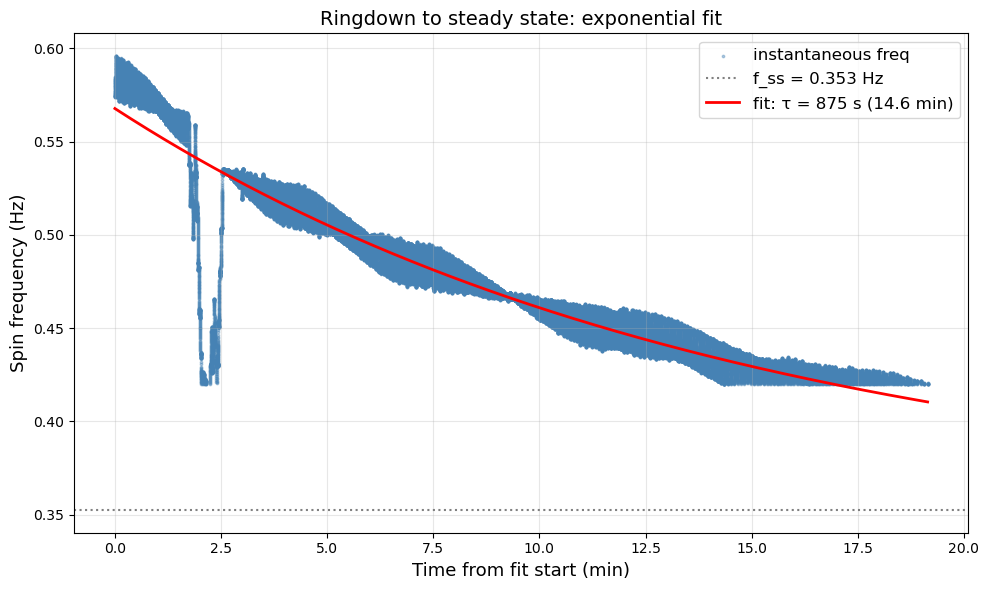

In [12]:
if len(f_fit) >= 20:
    t_curve = np.linspace(t_s[0], t_s[-1], 1000)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(t_s / 60, f_fit, s=3, alpha=0.4, color='steelblue', label='instantaneous freq')
    ax.axhline(f_ss, color='gray', linestyle=':', linewidth=1.5, label=f'f_ss = {f_ss:.3f} Hz')
    ax.plot(t_curve / 60, exp_decay_ss(t_curve, *popt), 'r-', linewidth=2,
            label=f'fit: τ = {tau:.0f} s ({tau/60:.1f} min)')
    ax.set_xlabel('Time from fit start (min)', fontsize=13)
    ax.set_ylabel('Spin frequency (Hz)', fontsize=13)
    ax.set_title('Ringdown to steady state: exponential fit', fontsize=14)
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

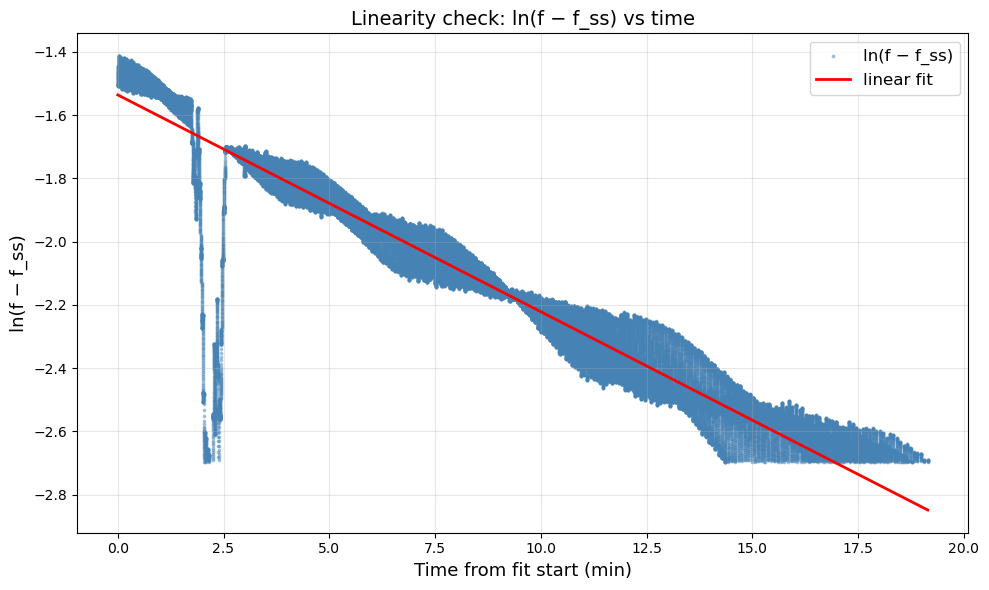

In [13]:
# Linearity check: ln(f - f_ss) vs time should be straight for pure exponential
if len(f_fit) >= 20:
    valid = f_fit > f_ss
    if valid.sum() < 10:
        print("WARNING: f_fit <= f_ss for many points — check f_ss estimate")
    else:
        t_lin = t_s[valid]
        ln_diff = np.log(f_fit[valid] - f_ss)

        fig, ax = plt.subplots(figsize=(10, 6))
        ax.scatter(t_lin / 60, ln_diff, s=3, alpha=0.4, color='steelblue', label='ln(f − f_ss)')
        ax.plot(t_curve / 60, np.log(A_fit) - gamma_fit * t_curve, 'r-',
                linewidth=2, label='linear fit')
        ax.set_xlabel('Time from fit start (min)', fontsize=13)
        ax.set_ylabel('ln(f − f_ss)', fontsize=13)
        ax.set_title('Linearity check: ln(f − f_ss) vs time', fontsize=14)
        ax.legend(fontsize=12)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

## 6. Results Summary

In [15]:
if len(f_fit) >= 20:
    print("=" * 40)
    print("RINGDOWN RESULTS")
    print("=" * 40)
    print(f"Decay constant:    γ = {gamma_fit:.6f} ± {gamma_err:.6f} s⁻¹")
    print(f"Ringdown time:     τ = {tau:.1f} ± {tau_err:.1f} s")
    print(f"                     = {tau/60:.2f} ± {tau_err/60:.2f} min")
    print(f"Amplitude:         A = {A_fit:.4f} Hz")
    print(f"Steady-state:  f_ss = {f_ss:.4f} Hz")
    print(f"Fit region:  {F_MIN_FIT}–{F_MAX_FIT} Hz  ({len(f_fit)} points)")
    print(f"Smoothing:   {SMOOTH_SEC}s window")

RINGDOWN RESULTS
Decay constant:    γ = 0.001142 ± 0.000002 s⁻¹
Ringdown time:     τ = 875.4 ± 1.3 s
                     = 14.59 ± 0.02 min
Amplitude:         A = 0.2151 Hz
Steady-state:  f_ss = 0.3526 Hz
Fit region:  0.42–0.95 Hz  (63984 points)
Smoothing:   30.0s window
